In [1]:
import pandas as pd
import numpy as np
import random
import seaborn as sns
import scipy.stats as ss
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportion_confint
from random import randint
from statsmodels.stats.power import tt_ind_solve_power
from statsmodels.stats.proportion import proportions_ztest

# Выборки

## Типы выборок

Научимся формировать различные типы выборок на данных

### Простая случайная выборка

In [2]:
np.random.seed(4)
# генерация совокупности данных, подчиняющихся нормальному распределению
N = 100000 # совокупность данных на примере 10 тыс.значений
mu = 10   # среднее совокупности
std = 2   # среднеквадратичное отклонение

#генерируем 10000 нормально распределенный случайных величин из распределения с заданными параметрами
population_data = np.random.normal(mu, std, N)

# задаем размер требуемой случайной выборки
n = 100

# функция, которая которая формирует случайную выборку из n-элементов
def random_sampling(array, n):
    random_sample = np.random.choice(array, replace = False, size = n) # replace = True, если требуется выборка с возвратом
    return(random_sample)
np.random.seed(1) # важно не забывать про seed, чтобы результаты деления были воспроизводимы
random_sample = random_sampling(population_data, n)
random_sample

array([10.38619206,  7.38599531,  7.64656447,  8.74616764,  9.77133774,
       10.43216963, 10.27442803,  8.08073798,  9.50418917, 11.11870389,
       10.01156568,  8.38206823,  6.78498211, 12.43800671,  6.45846646,
       10.30648122, 10.70477484,  5.76169556, 12.84665897, 14.40606671,
        4.94334909, 12.53407673, 12.41592896,  9.82431532,  9.90170938,
       12.71411917, 11.55170334, 11.67852896, 13.23749388, 10.9438594 ,
       10.28694784,  8.25347796,  9.69308609,  7.92267363,  8.25295533,
        7.7306579 ,  8.91371596,  9.85977693,  8.97628763,  8.90670266,
        9.22660441,  6.37393319, 11.49951976,  5.31462453,  8.75657127,
        8.80072866,  9.32718716, 13.35937557, 10.63525571, 16.04250064,
        9.62966706, 10.94110928,  4.99526754,  8.6513997 , 13.18075112,
       10.99677714, 10.52005388, 13.91005889, 10.49100892,  9.54833282,
       10.4780189 , 10.80073783, 14.52917796, 10.61990131,  8.71091885,
        6.95676365,  9.70457872, 10.53661008,  9.39604972,  9.67

<AxesSubplot:ylabel='Density'>

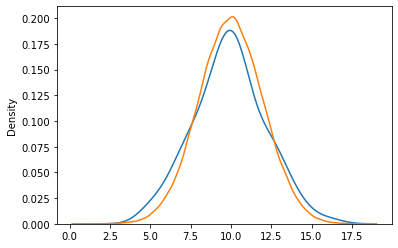

In [3]:
# посмотрим не различается ли распределение выборки от генеральной совокупности
sns.kdeplot(random_sample)
sns.kdeplot(population_data)

In [4]:
# другой вариант рассчета простой случайной выборки
# иногда удобно хранить деление на выборку в виде маски булевых значений
np.random.seed(1) # важно не забывать про seed, чтобы результаты деления были воспроизводимы
sample_mask = ss.bernoulli.rvs(0.5, size=len(population_data)) # 0.5 - вероятность попадания в выборку
sample_mask
print('Mean', np.mean(population_data[sample_mask==1]))
population_data[sample_mask==1]

Mean 9.993970884191873


array([10.99990267,  7.70504673,  9.82402614, ...,  6.52446045,
        5.97315951, 12.28397835])

In [5]:
print('Размер выборки полученный через маску:', len(population_data[sample_mask==1]))
print('Размер генеральной совокупности:', len(population_data))

Размер выборки полученный через маску: 49986
Размер генеральной совокупности: 100000


<AxesSubplot:ylabel='Density'>

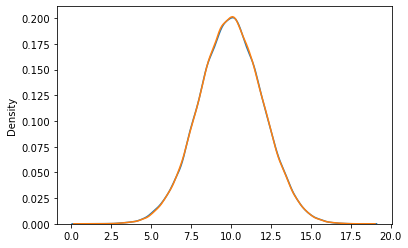

In [6]:
sns.kdeplot(population_data[sample_mask==1])
sns.kdeplot(population_data)

In [7]:
# другой вариант рассчета простой случайной выборки
# Также можно использовать функцию sample в Pandas. Удобно когда вы хотите сэмплировать датафрейм.

In [8]:
# сделаем dataframe
population_dataframe = pd.DataFrame({'population_data': population_data,
             'user_id': np.arange(len(population_data))})
population_dataframe

,population_data,user_id
0,10.101123,0
1,10.999903,1
2,8.008182,2
3,11.387197,3
4,9.163397,4
...,...,...
99995,8.901596,99995
99996,11.949173,99996
99997,6.524460,99997
99998,5.973160,99998


In [9]:
# используем функцию sample из Pandas
np.random.seed(1) # важно не забывать про seed, чтобы результаты деления были воспроизводимы
random_sample = population_dataframe.sample(frac = 0.5, random_state = 1)
print('sample_size =', len(random_sample))
print('sample mean =', random_sample['population_data'].mean())
random_sample.head(5)

sample_size = 50000
sample mean = 9.99103115502391


,population_data,user_id
43660,10.386192,43660
87278,7.385995,87278
14317,7.646564,14317
81932,8.746168,81932
95321,9.771338,95321


<AxesSubplot:xlabel='population_data', ylabel='Density'>

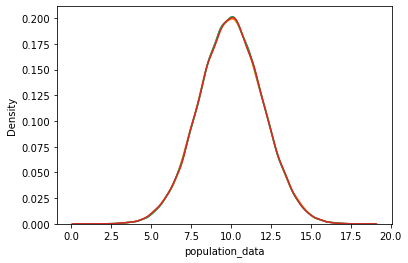

In [10]:
# посмотрим визуально не различаются ли простые случайные выборки сгенерированные различными способами
sns.kdeplot(population_dataframe['population_data'])

sns.kdeplot(random_sample['population_data'])
sns.kdeplot(population_dataframe['population_data'])
sns.kdeplot(population_data[sample_mask==1])

### Систематическая (интервальная) случайная выборка

In [11]:
# функция, которая формирует систематическую случайную выборку из n-элементов
def systematic_sampling(df, step):
    id = pd.Series(np.arange(0, len(df), 1))
    df = pd.Series(df)
    df_pd = pd.concat([id, df], axis = 1)
    df_pd.columns = ["id", "data"]

    # определяем первый случайный элемент выборки и передаем интервал
    first = np.random.randint(0, 10)
    selected_index = np.arange(first, len(df), step)

    # формируем датасет систематической выборки
    systematic_sampling = df_pd.iloc[selected_index]
    return(systematic_sampling)

# задаем размер выборки и вычисляем интервал из совокупности данных
n = 10000 # желаемый размер выборки
step = int(N/n)

systematic_sample = systematic_sampling(population_dataframe['population_data'], step)
systematic_sample

,id,data
5,5,6.830846
15,15,10.701994
25,25,10.788590
35,35,11.675673
45,45,11.604173
...,...,...
99955,99955,11.008031
99965,99965,13.608301
99975,99975,8.482935
99985,99985,11.650167


<AxesSubplot:xlabel='data', ylabel='Density'>

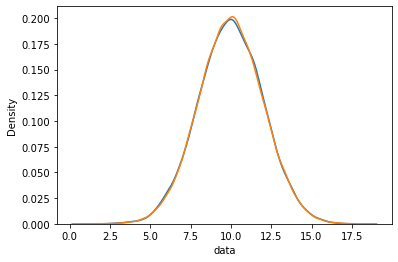

In [12]:
# посмотрим визуально на функцию плотности ген совокупности и случайной выборки
sns.kdeplot(systematic_sample['data'])
sns.kdeplot(population_dataframe['population_data'])

### Кластерная случайная выборка

In [13]:
# генерация совокупности данных
price_vb = pd.Series(np.random.uniform(1,4,size = N))
id = pd.Series(np.arange(0,len(price_vb),1))
event_type = pd.Series(np.random.choice(['type1','type2','type3'], size = len(price_vb)))
click = pd.Series(ss.bernoulli.rvs(0.5, size=len(price_vb)))
df = pd.concat([id,price_vb,event_type, click],axis = 1)
df.columns = ['id', 'price', 'event_type', 'click']
df.head()

,id,price,event_type,click
0,0,3.991554,type2,0
1,1,3.797672,type1,1
2,2,1.384373,type3,0
3,3,3.997122,type2,1
4,4,1.708267,type2,0


In [14]:
# создадим функцию, которая из датасета делает кластерную выборку.
# В реальности кластера это определенные группы имеющиеся априори. Например школы. Но для симуляции попробуем создавать их синтетически

def get_clustered_sample(df, n_per_cluster, num_select_clusters):

    N = len(df) # Размер датасета
    K = int(N/n_per_cluster) # кол-во кластеров
    data = None

    for k in range(K):
        sample_k = df.sample(n_per_cluster)  #рандомно формируем требуемую случайную выборку
        sample_k['cluster'] = np.repeat(k,len(sample_k)) # повторением получаем номер кластера для всех элементов группы в этой итерации
                                                        # (при следующем цикле k-группы номер кластера будет другой)

        df = df.drop(index = sample_k.index) # избавляемся от индекса в датасете номера кластера
        data = pd.concat([data,sample_k],axis = 0) # добавляем номер кластера к данным выборки

    random_chosen_clusters = np.random.choice(data['cluster'].unique(), size = num_select_clusters, replace = False) #формируем выборку из номеров кластеров нужного размера
    samples = data[data.cluster.isin(random_chosen_clusters)] # для случайно выбранных 2-х кластеров извлекаем данные
    return(samples)

clust_sample = get_clustered_sample(df = df, n_per_cluster = 50, num_select_clusters = 50)
clust_sample

,id,price,event_type,click,cluster
9145,9145,2.289775,type2,0,125
44392,44392,3.163369,type3,1,125
16644,16644,2.963228,type1,1,125
90023,90023,1.230639,type3,1,125
43161,43161,2.512260,type2,0,125
...,...,...,...,...,...
51356,51356,3.304182,type1,1,1916
40127,40127,3.756237,type2,1,1916
37675,37675,3.218188,type3,1,1916
65308,65308,1.807441,type3,0,1916


<AxesSubplot:xlabel='price', ylabel='Density'>

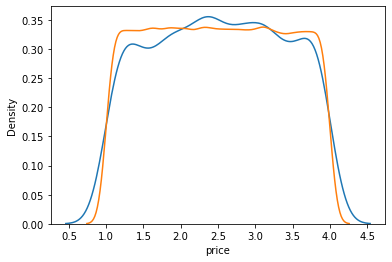

In [15]:
# посмотрим визуально распределения в ген совокупности и кластерной выборке
sns.kdeplot(clust_sample['price'])
sns.kdeplot(df['price'])

### Стратифицированная случайная выборка

#### вариант №1

Подготовим датасет, включающий данные о том, пользуется ли пользователь дополнительными платными услугами и какую платформу использует для доступа к приложению:
- Доля платящих пользователей (обозначены 1) равна 20%,
- Платформы распределены в соотношении 70% Android и 30% iOS

In [16]:
# Подготовим датасет из 100 тыс.пользователей
n_rows = 100000
df = pd.DataFrame(dict(
    user_id = np.arange(0, n_rows),
    vas = np.random.binomial(1, 0.2, size=n_rows), # зададим флаг были ли покупки vas услуг
    platform = random.choices(['android', 'ios'], weights=(70, 30), k=n_rows) # рандомно присвоим платформу с заданными вероятностями
))

# проверим соотношение типов пользователей по платежному поведению и платформам в сгенерированном датасете
print(df[['vas','platform']].value_counts())
df.head()

vas  platform
0    android     56239
     ios         23719
1    android     13920
     ios          6122
dtype: int64


,user_id,vas,platform
0,0,0,android
1,1,0,android
2,2,0,ios
3,3,0,android
4,4,0,android


In [17]:
# Получим 5%-ю стратифицированную выборку по платформе
strat_sample_dataset_1 = (df.groupby(['vas','platform'], group_keys = False)
                    .apply(lambda x: x.sample(frac=0.005)))

In [18]:
strat_sample_dataset_1

,user_id,vas,platform
46505,46505,0,android
31913,31913,0,android
20005,20005,0,android
86021,86021,0,android
9917,9917,0,android
...,...,...,...
40807,40807,1,ios
62392,62392,1,ios
77828,77828,1,ios
836,836,1,ios


In [19]:
# Получим 5%-ю простую случайную выборку по платформе
random_df_sample = df.sample(frac = 0.005)

In [20]:
# проверим соотношение платящих и не платящих пользователей в выборке
print('Доля платящих пользователей в ген совокупности:', df['vas'].mean())
print('Доля платящих пользователей в стратифицированной выборке:', strat_sample_dataset_1['vas'].mean())
print('Доля платящих пользователей в случайной выборке:', random_df_sample['vas'].mean())

Доля платящих пользователей в ген совокупности: 0.20042
Доля платящих пользователей в стратифицированной выборке: 0.20159680638722555
Доля платящих пользователей в случайной выборке: 0.194


Как видно из долей выше на небольшой выборке стратифицированный алгоритм показывает более близкое к ген совокупности распределение доли платящих

In [21]:
# проверим как представлены платформы в выборке

print('Доля android в генеральной совокупности:', (df['platform']=='android').mean())
print('Доля android в стратифицированной выборке:', (strat_sample_dataset_1['platform']=='android').mean())
print('Доля android в случайной выборке:', (random_df_sample['platform']=='android').mean())

Доля android в генеральной совокупности: 0.70159
Доля android в стратифицированной выборке: 0.7005988023952096
Доля android в случайной выборке: 0.746


#### Вариант 2. (дополнительный) Альтернативный вариант, используя параметр веса:
- этого варианта не было в видео лекции. но он пригодится для решения домашнего задания
- данный метод показывает более высокую точность стратификации

In [22]:
def population_sample_parameter(dataset, column):
    '''фунция определяет долю значений для выбранного параметра в полном наборе данных'''
    print(column)
    print(dataset[column].value_counts(normalize = True).to_string())
    print('-------------')

print('Доля значений параметра в полном наборе данных:')
parameter_list = ['vas','platform']
for step in parameter_list:
    population_sample_parameter(df, step)

# сформируем выборку из 10 тыс. пользователей, исходя из условия,
# что параметры представлены в соотношении, как для полного набора данных

df['combined'] = (
    list(zip(df['vas'],
             df['platform']))
) #формируем столбец с комбинацией целевых параметров

weight = df['combined'].value_counts(normalize=True)
counts = df['combined'].value_counts()

df['combined_weight'] = df['combined'].apply(lambda x: weight[x]/counts[x]) # рассчитываем вес каждой комбинации по которому будет сэплироваться выборка
strat_sample_dataset_2 = df.sample(10000, weights=df['combined_weight']) # сэмплируем по весам комбинации параметров

# выведем долю значений для каждого параметра в выборке
print('Доля значений параметра в выборке из 10 тыс. пользователей:')
for step in parameter_list:
    population_sample_parameter(strat_sample_dataset_2, step)

Доля значений параметра в полном наборе данных:
vas
0    0.79958
1    0.20042
-------------
platform
android    0.70159
ios        0.29841
-------------
Доля значений параметра в выборке из 10 тыс. пользователей:
vas
0    0.8045
1    0.1955
-------------
platform
android    0.7108
ios        0.2892
-------------


In [23]:
# выведем долю значений для каждого параметра в выборке
print('Доля значений параметра в выборке из 10 тыс. пользователей:')
for step in parameter_list:
    population_sample_parameter(df, step)

Доля значений параметра в выборке из 10 тыс. пользователей:
vas
0    0.79958
1    0.20042
-------------
platform
android    0.70159
ios        0.29841
-------------


In [24]:
# проверим как представлены платформы в выборке

print('Доля android в генеральной совокупности:', (df['platform']=='android').mean())
print('Доля android в стратифицированной выборке (вариант 1):', (strat_sample_dataset_1['platform']=='android').mean())
print('Доля android в стратифицированной выборке (вариант 2):', (strat_sample_dataset_2['platform']=='android').mean())
print('Доля android в случайной выборке:', (random_df_sample['platform']=='android').mean())

Доля android в генеральной совокупности: 0.70159
Доля android в стратифицированной выборке (вариант 1): 0.7005988023952096
Доля android в стратифицированной выборке (вариант 2): 0.7108
Доля android в случайной выборке: 0.746


## Поработаем с реальными данными

#### Получение данных о пользователях из базы

SELECT

up.execution_date,

up.created_at,

up.passport_id,

up.global_id,

up.user_type_cars_name

FROM `user_passports_res_anon` AS up

ORDER BY up.execution_date


In [25]:
df_user_passports = pd.read_csv('user_passports.csv', encoding = 'utf-8')
df_user_passports.head(5)

,execution_date,passport_id,global_id,login,created_at,user_type_id,user_type_name,user_type_changed_at,user_type_cars_id,user_type_cars_name,user_type_cars_changed_at
0,2022-10-09,124025991,124004987,VmDe/C8T2IDkaDjxIZ+4PA==,2013-03-28 13:46:39,0,simple_user,NaN,0,cars_simple,NaN
1,2022-10-09,142763752,147740704,ykf6nPFfGDOmvQ8+Wm7IFA==,2021-12-22 17:35:16,0,simple_user,NaN,0,cars_simple,NaN
2,2022-10-09,135557519,139948206,cim2q5xvQIWCapTXUhF0zg==,2019-07-30 17:04:46,0,simple_user,NaN,0,cars_simple,NaN
3,2022-10-09,133420705,136724165,UIobyHts94BY2MD1LbwNGA==,2018-11-07 23:46:45,0,simple_user,NaN,0,cars_simple,NaN
4,2022-10-09,140030534,144336261,28/pxuvy7mrZYZXi1buenQ==,2020-11-14 21:39:58,0,simple_user,NaN,0,cars_simple,NaN


In [26]:
# Рандомная выборка с присвоением контрольной или тестовой группы

np.random.seed(3) # важно не забывать про seed, чтобы результаты деления были воспроизводимы
sample_mask = ss.bernoulli.rvs(0.8, size=len(df_user_passports)) # 0.
df_user_passports['simple_random_group'] = sample_mask

df_user_passports['simple_random_group'].value_counts(normalize = True)

1    0.802391
0    0.197609
Name: simple_random_group, dtype: float64

In [27]:
df_user_passports.head()

,execution_date,passport_id,global_id,login,created_at,user_type_id,user_type_name,user_type_changed_at,user_type_cars_id,user_type_cars_name,user_type_cars_changed_at,simple_random_group
0,2022-10-09,124025991,124004987,VmDe/C8T2IDkaDjxIZ+4PA==,2013-03-28 13:46:39,0,simple_user,NaN,0,cars_simple,NaN,1
1,2022-10-09,142763752,147740704,ykf6nPFfGDOmvQ8+Wm7IFA==,2021-12-22 17:35:16,0,simple_user,NaN,0,cars_simple,NaN,1
2,2022-10-09,135557519,139948206,cim2q5xvQIWCapTXUhF0zg==,2019-07-30 17:04:46,0,simple_user,NaN,0,cars_simple,NaN,1
3,2022-10-09,133420705,136724165,UIobyHts94BY2MD1LbwNGA==,2018-11-07 23:46:45,0,simple_user,NaN,0,cars_simple,NaN,1
4,2022-10-09,140030534,144336261,28/pxuvy7mrZYZXi1buenQ==,2020-11-14 21:39:58,0,simple_user,NaN,0,cars_simple,NaN,0


In [28]:
len(df_user_passports)

9367

## Использование Hash-функций для рандомизации

In [29]:
!pip install murmurhash2
import hashlib
from murmurhash2 import murmurhash2, murmurhash3

df_user_passports['global_id'] = df_user_passports['global_id'].astype(str)

df_user_passports['md5'] = (
    [hashlib.md5(val.encode('UTF-8')).hexdigest() for val in df_user_passports['global_id']]
)

df_user_passports['md5'] = df_user_passports['md5'].apply(int, base=16)

# Рандомизация зарегистрированных пользователей по бакетам с использованием остатка от деления

# отрезаем последний символ id (может быть нерандомным)
df_user_passports['global_id_transformed'] = df_user_passports['md5'] // 10

# используем остаток от деления id пользователя для распределения по бакетам для md5
df_user_passports['bucket_id'] = df_user_passports['global_id_transformed'] % 100

print('Размер исходного датасета', len(df_user_passports))
df_user_passports.groupby(['bucket_id']).count()['passport_id']

Размер исходного датасета 9367


bucket_id
0      88
1     107
2      81
3      88
4      99
     ... 
95    106
96    101
97     93
98     81
99    100
Name: passport_id, Length: 100, dtype: int64

In [30]:
df_user_passports.head()

,execution_date,passport_id,global_id,login,created_at,user_type_id,user_type_name,user_type_changed_at,user_type_cars_id,user_type_cars_name,user_type_cars_changed_at,simple_random_group,md5,global_id_transformed,bucket_id
0,2022-10-09,124025991,124004987,VmDe/C8T2IDkaDjxIZ+4PA==,2013-03-28 13:46:39,0,simple_user,NaN,0,cars_simple,NaN,1,300480812144854033254122193569131109097,30048081214485403325412219356913110909,9
1,2022-10-09,142763752,147740704,ykf6nPFfGDOmvQ8+Wm7IFA==,2021-12-22 17:35:16,0,simple_user,NaN,0,cars_simple,NaN,1,95113019812368846327928754511395983931,9511301981236884632792875451139598393,93
2,2022-10-09,135557519,139948206,cim2q5xvQIWCapTXUhF0zg==,2019-07-30 17:04:46,0,simple_user,NaN,0,cars_simple,NaN,1,248958859067613554490456990646941501831,24895885906761355449045699064694150183,83
3,2022-10-09,133420705,136724165,UIobyHts94BY2MD1LbwNGA==,2018-11-07 23:46:45,0,simple_user,NaN,0,cars_simple,NaN,1,187479745211920398225691779451573368650,18747974521192039822569177945157336865,65
4,2022-10-09,140030534,144336261,28/pxuvy7mrZYZXi1buenQ==,2020-11-14 21:39:58,0,simple_user,NaN,0,cars_simple,NaN,0,264181220687091912395873616418528643636,26418122068709191239587361641852864363,63


In [31]:
# другие варианты хеш-функций
# хеш-функция mumurhash2
seed = 1
df_user_passports['mumurhash2'] = (
    [murmurhash2(val.encode('UTF-8'), seed) for val in df_user_passports['global_id']]
)

# хеш-функция spookyhash
!pip install spookyhash

import spookyhash
df_user_passports['spookyhash'] = (
    [spookyhash.hash32(val.encode('UTF-8'), seed) for val in df_user_passports['global_id']]
)

In [32]:
df_user_passports.head()

,execution_date,passport_id,global_id,login,created_at,user_type_id,user_type_name,user_type_changed_at,user_type_cars_id,user_type_cars_name,user_type_cars_changed_at,simple_random_group,md5,global_id_transformed,bucket_id,mumurhash2,spookyhash
0,2022-10-09,124025991,124004987,VmDe/C8T2IDkaDjxIZ+4PA==,2013-03-28 13:46:39,0,simple_user,NaN,0,cars_simple,NaN,1,300480812144854033254122193569131109097,30048081214485403325412219356913110909,9,2056483722,3783523981
1,2022-10-09,142763752,147740704,ykf6nPFfGDOmvQ8+Wm7IFA==,2021-12-22 17:35:16,0,simple_user,NaN,0,cars_simple,NaN,1,95113019812368846327928754511395983931,9511301981236884632792875451139598393,93,2660533847,805114337
2,2022-10-09,135557519,139948206,cim2q5xvQIWCapTXUhF0zg==,2019-07-30 17:04:46,0,simple_user,NaN,0,cars_simple,NaN,1,248958859067613554490456990646941501831,24895885906761355449045699064694150183,83,1078280488,1663311133
3,2022-10-09,133420705,136724165,UIobyHts94BY2MD1LbwNGA==,2018-11-07 23:46:45,0,simple_user,NaN,0,cars_simple,NaN,1,187479745211920398225691779451573368650,18747974521192039822569177945157336865,65,664369164,458675156
4,2022-10-09,140030534,144336261,28/pxuvy7mrZYZXi1buenQ==,2020-11-14 21:39:58,0,simple_user,NaN,0,cars_simple,NaN,0,264181220687091912395873616418528643636,26418122068709191239587361641852864363,63,2426260465,2065425089


In [33]:
# используем остаток от деления id пользователя для распределения по бакетам для mumurhash2. Делим на 100 бакетов
df_user_passports['bucket'] = df_user_passports['mumurhash2'] % 100

# разделяем на группы в соотнноении 80:20 (все бакеты до 80 относятся к группе А1)
df_user_passports['bucket_group'] = np.where(df_user_passports['bucket'] <= 80, 'A', 'B')

In [34]:
df_user_passports.head()

,execution_date,passport_id,global_id,login,created_at,user_type_id,user_type_name,user_type_changed_at,user_type_cars_id,user_type_cars_name,user_type_cars_changed_at,simple_random_group,md5,global_id_transformed,bucket_id,mumurhash2,spookyhash,bucket,bucket_group
0,2022-10-09,124025991,124004987,VmDe/C8T2IDkaDjxIZ+4PA==,2013-03-28 13:46:39,0,simple_user,NaN,0,cars_simple,NaN,1,300480812144854033254122193569131109097,30048081214485403325412219356913110909,9,2056483722,3783523981,22,A
1,2022-10-09,142763752,147740704,ykf6nPFfGDOmvQ8+Wm7IFA==,2021-12-22 17:35:16,0,simple_user,NaN,0,cars_simple,NaN,1,95113019812368846327928754511395983931,9511301981236884632792875451139598393,93,2660533847,805114337,47,A
2,2022-10-09,135557519,139948206,cim2q5xvQIWCapTXUhF0zg==,2019-07-30 17:04:46,0,simple_user,NaN,0,cars_simple,NaN,1,248958859067613554490456990646941501831,24895885906761355449045699064694150183,83,1078280488,1663311133,88,B
3,2022-10-09,133420705,136724165,UIobyHts94BY2MD1LbwNGA==,2018-11-07 23:46:45,0,simple_user,NaN,0,cars_simple,NaN,1,187479745211920398225691779451573368650,18747974521192039822569177945157336865,65,664369164,458675156,64,A
4,2022-10-09,140030534,144336261,28/pxuvy7mrZYZXi1buenQ==,2020-11-14 21:39:58,0,simple_user,NaN,0,cars_simple,NaN,0,264181220687091912395873616418528643636,26418122068709191239587361641852864363,63,2426260465,2065425089,65,A


In [35]:
df_user_passports['bucket_group']

0       A
1       A
2       B
3       A
4       A
       ..
9362    A
9363    A
9364    A
9365    A
9366    A
Name: bucket_group, Length: 9367, dtype: object

In [36]:
df_user_passports.head(2)

,execution_date,passport_id,global_id,login,created_at,user_type_id,user_type_name,user_type_changed_at,user_type_cars_id,user_type_cars_name,user_type_cars_changed_at,simple_random_group,md5,global_id_transformed,bucket_id,mumurhash2,spookyhash,bucket,bucket_group
0,2022-10-09,124025991,124004987,VmDe/C8T2IDkaDjxIZ+4PA==,2013-03-28 13:46:39,0,simple_user,NaN,0,cars_simple,NaN,1,300480812144854033254122193569131109097,30048081214485403325412219356913110909,9,2056483722,3783523981,22,A
1,2022-10-09,142763752,147740704,ykf6nPFfGDOmvQ8+Wm7IFA==,2021-12-22 17:35:16,0,simple_user,NaN,0,cars_simple,NaN,1,95113019812368846327928754511395983931,9511301981236884632792875451139598393,93,2660533847,805114337,47,A


In [37]:
# стратифицированная выборка по типу пользователя
df_sample = (
    df_user_passports.groupby(['user_type_cars_name'], group_keys=False)
                     .apply(lambda x:x.sample(frac=0.2))
)

df_sample['user_type_cars_name'].value_counts(normalize = True)

cars_simple    0.937533
cars_seller    0.056594
cars_dealer    0.005873
Name: user_type_cars_name, dtype: float64

In [38]:
# исходное распределение по типу пользователя
df_user_passports['user_type_cars_name'].value_counts(normalize = True)

cars_simple    0.937440
cars_seller    0.056475
cars_dealer    0.006085
Name: user_type_cars_name, dtype: float64

In [39]:
# исходное распределение по типу пользователя
df_user_passports[df_user_passports['simple_random_group'] == 1]['user_type_cars_name'].value_counts(normalize = True)

cars_simple    0.936801
cars_seller    0.056812
cars_dealer    0.006386
Name: user_type_cars_name, dtype: float64

In [40]:
# распределение по типу пользователя в простой случайной выборке
df_user_passports[df_user_passports['simple_random_group'] == 0]['user_type_cars_name'].value_counts(normalize = True)

cars_simple    0.940032
cars_seller    0.055105
cars_dealer    0.004862
Name: user_type_cars_name, dtype: float64

In [41]:
# распределение по группам в разрезе дилеров 80:20
df_sample[df_sample['user_type_cars_name'] == 'cars_dealer']['bucket_group'].value_counts()

A    9
B    2
Name: bucket_group, dtype: int64

## Проверка на несбалансированность выборки (SRM)

[Ссылка на статью о причинах возникновения SRM (англ.)](fabijan2019.pdf)

**Гипотезы:**
- H0 - соотношение между размерами выборок 1:1
- Ha - соотношение между размерами выборок не 1:1

**1. Проверка, используя тест Chi-square**

![chi_square.png](attachment:chi_square.png)

In [42]:
# введите текущее число пользователей в тестовой и контрольной группах
observed = [170471, 170462]

# введите соотношение между двумя группами (достаточно % для одной из групп)
ratio = 50

# введите уровень значимости
alpha = 0.05

In [43]:
total_traffic = sum(observed)

expected = [ (total_traffic * ratio)/100, (total_traffic * (100 - ratio)/100) ] # ожидаемые размеры групп если бы ratio выполнялось полностью
print('Real sample sizes:', observed)
print('Expected sample sizes:', expected)

chi = ss.chisquare(observed, f_exp = expected) # считаем результаты точечной оценки доли через хи-квадрат критерий

if chi[1] < alpha:
    print('SRM, присутствует!!!')
else:
    print('SRM отсутствует')
print(chi)

Real sample sizes: [170471, 170462]
Expected sample sizes: [170466.5, 170466.5]
SRM отсутствует
Power_divergenceResult(statistic=0.00023758333748859746, pvalue=0.9877021029149465)


**2. Проверка, используя z-тест с одной пропорцией**

![z_test.png](attachment:z_test.png)

In [44]:
#z-тест на одну пропорцию
stat, pval = proportions_ztest(count=observed[0], nobs=sum(observed), value=0.5) # считаем точечную оценку доли для z-теста
print('Z-статистика: ', stat, '\np-value: ', pval)

if pval < alpha:
    print('SRM при выбранном alpha присутствует')
else:
    print('SRM отсутствует')

Z-статистика:  0.015413738600868329 
p-value:  0.9877021029106169
SRM отсутствует


Michael Lindon
A Better Way to Test for Sample Ratio Mismatches (SRMs) and Validate Experiment Implementations </br>
https://medium.com/engineers-optimizely/a-better-way-to-test-for-sample-ratio-mismatches-srms-and-validate-experiment-implementations-6da7c0d64552
    

Код от Optimizely </br>
https://github.com/michaellindon/ssrm </br>

https://github.com/michaellindon/ssrm/blob/master/notebooks/introduction.ipynb (обучающий блокнот)


## 3. Проверка, используя SSRM (Optimizely) последовательное наблюдение за SRM

In [45]:
# установка модуля SSRM
!pip install ssrm-test --user

In [46]:
from scipy.stats import multinomial
from ssrm_test import ssrm_test
np.random.seed(1)

# Планируемое распределение трафика между группами
p_0 = [0.5, 0.5]

# Реальное распределение трафика между группами
p = [0.51, 0.49]

# Заданное число пользователей (большой размер выбори потребует время для проведения вычислений)
n = 163707

# Получение синтетических данных
data = multinomial.rvs(1, p, size=n)

x = np.sum(data, axis=0)[0]
print(
    "Распределение трафика между группами, полученное в ходе эксперимента: {}% и {}%".format(
        round(100 * x / n, 1), round(100 * (n - x) / n, 1)
    )
)

Распределение трафика между группами, полученное в ходе эксперимента: 50.9% и 49.1%


In [47]:
# проверим видит ли SRM z-test
z_test = proportions_ztest(count=x, nobs=n, value=0.5)

print("{} пользователей для контрольной группы".format(x))
print("p-value: {}".format(z_test[1]))

83329 пользователей для контрольной группы
p-value: 2.993730802319865e-13


Вычисляю... (может занять время)


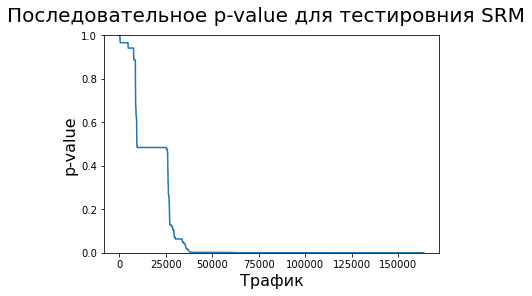

In [48]:
print("Вычисляю... (может занять время)")
pvals = ssrm_test.sequential_p_values(data, p_0)
fig = plt.figure()
plt.plot(pvals)
fig.suptitle("Последовательное p-value для тестировния SRM", fontsize=20)
plt.xlabel("Трафик", fontsize=16)
plt.ylabel("p-value", fontsize=16)
plt.ylim(0, 1)
plt.show()

In [49]:
sig_reached = np.argmax(np.array(pvals) < 0.05)
print(
    "SSRM отклонило нулевую гипотезу об отсутствии SRM при уровне значимости alpha=0.05 после {} пользователей".format(
        sig_reached
    )
)
print(
    "Это {}% от общего числа пользователей для этого эксперимента".format(
        round(100 * sig_reached / n), 3
    )
)

SSRM отклонило нулевую гипотезу об отсутствии SRM при уровне значимости alpha=0.05 после 34386 пользователей
Это 21% от общего числа пользователей для этого эксперимента


## Влияние объёма трафика на SRM

Более детальные симуляции: </br>
https://towardsdatascience.com/sample-ratio-mismatch-so-many-questions-how-to-answer-them-a86a1893e35

https://towardsdatascience.com/the-essential-guide-to-sample-ratio-mismatch-for-your-a-b-tests-96a4db81d7a4

Text(0.5, 1.0, 'Влияние трафика на доверительный интервал оценки попадания в выборкус 50% вероятностью, который возможно задетектить (alpha = 0.05)')

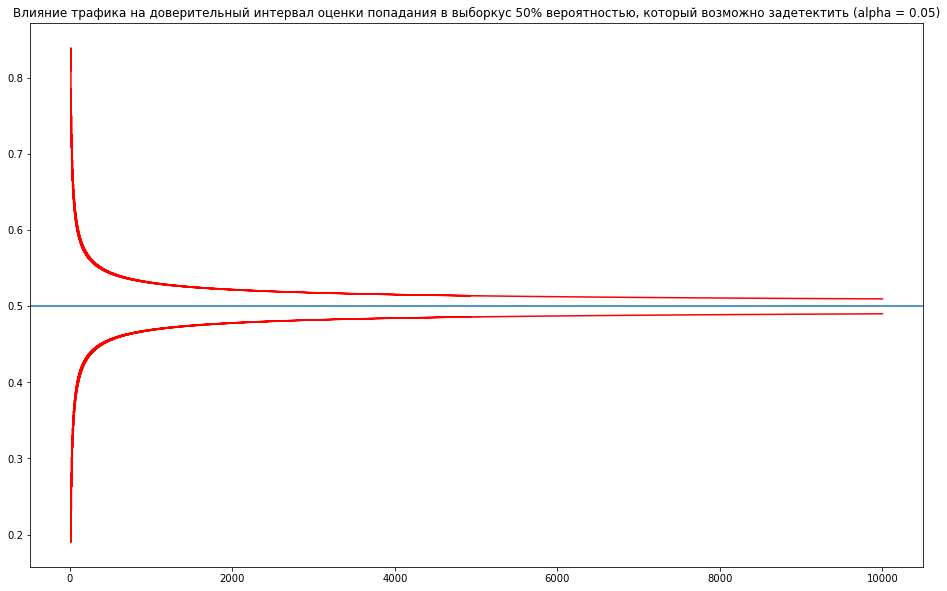

In [50]:
traffic = np.arange(10, 10000)
p = 0.5
upper_ci_list = []
lower_ci_list = []
for i in traffic:
    ci = proportion_confint(round(i*p), i, alpha = 0.05)
    lower_ci_list.append(ci[0])
    upper_ci_list.append(ci[1])
plt.figure(figsize=(16,10))
sns.lineplot(x = traffic, y = lower_ci_list, color = 'red')
sns.lineplot(x = traffic, y = upper_ci_list, color = 'red')
plt.axhline(y = p)
plt.title('Влияние трафика на доверительный интервал оценки попадания в выборкус 50% вероятностью, который возможно задетектить (alpha = 0.05)')

In [51]:
n=100
p = 0.5
print('При {} наблюдениях, 95%-ДИ для {} доли одной группы составит: {}'. format(n, p, proportion_confint(round(n*0.5), n, alpha = 0.5)))

При 100 наблюдениях, 95%-ДИ для 0.5 доли одной группы составит: (0.46627551249019594, 0.5337244875098041)


## 4. Проверка выборки на репрезентативность

KS-test p-value 0.6077321516173053


<AxesSubplot:ylabel='Density'>

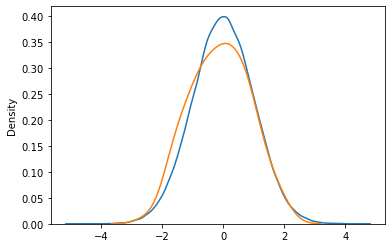

In [56]:
# Тест Колмогорова-Смирнова
rng=100
# Используем функцию нормального распределения в качестве генеральной совокупности
# Извлечем выборку из 100 элементов, подчиняющихся нормальному распределению
population = ss.norm.rvs(size=100000, random_state=rng)
x1 = ss.norm.rvs(size=100, random_state=rng)

# Проведем тест на репрезентативность выборки, используя критерий Колмогорова-Смирнова,
# где H0: выборка принадлежит нормальному распределению, alpha = 0.05
print('KS-test p-value', ss.kstest(x1, population)[1])

sns.kdeplot(population)
sns.kdeplot(x1)

KS-test p-value 9.532830292518639e-08


<AxesSubplot:ylabel='Density'>

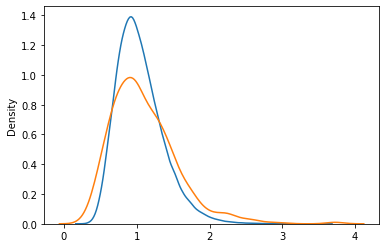

In [60]:
from scipy.stats import lognorm
# Проведем тест для выборки, которая получена из log-normal распределения

population = ss.lognorm.rvs(0.3, size=100000)
x2 = ss.lognorm.rvs(0.4, size=1000)
ss.kstest(x2, population)
print('KS-test p-value', ss.kstest(x2, population)[1])

sns.kdeplot(population)
sns.kdeplot(x2)

## 5.Несбалансированные выборки

In [61]:
sample_2, sample_1 = 50, 50
ratio =  sample_2 / sample_1
sample_1_size = tt_ind_solve_power(effect_size = 0.1,
                       alpha = 0.05,
                       power = 0.8,
                       ratio = ratio,
                       alternative = "two-sided",
                      nobs1 = None)
sample_2_size = sample_1_size/ratio
print('Размер выборки 1 равен: {}, Размер выборки 2 равен: {}'.format(round(sample_1_size), round(sample_2_size)))
print('Общая необходимая численность наблюдений = ', round(sample_1_size + sample_2_size))
#ratio : float
#    ratio of the number of observations in sample 2 relative to
#    sample 1. see description of nobs1
#    The default for ratio is 1; to solve for ratio given the other
#    arguments it has to be explicitly set to None.

Размер выборки 1 равен: 1571, Размер выборки 2 равен: 1571
Общая необходимая численность наблюдений =  3141


In [62]:
sample_2, sample_1 = 40, 60
ratio =  sample_2 / sample_1
sample_1_size = tt_ind_solve_power(effect_size = 0.1,
                       alpha = 0.05,
                       power = 0.8,
                       ratio = ratio,
                       alternative = "two-sided",
                      nobs1 = None)
sample_2_size = sample_1_size/ratio
print('Размер выборки 1 равен: {}, Размер выборки 2 равен: {}'.format(round(sample_1_size), round(sample_2_size)))
print('Общая необходимая численность наблюдений = ', round(sample_1_size + sample_2_size))


Размер выборки 1 равен: 1963, Размер выборки 2 равен: 2945
Общая необходимая численность наблюдений =  4908
